In [11]:
import os
import h5py
import numpy as np
import imageio.v3 as iio
import matplotlib.pyplot as plt


def get_ranges(trX, trY, screen_w, screen_h, img_w, img_h):
    ymin = (screen_h / 2) - trY + 1
    ymax = img_h + (screen_h / 2) - trY
    xmin = (screen_w / 2) - trX + 1
    xmax = img_w + (screen_w / 2) - trX

    ymin = max(1, ymin)
    xmin = max(1, xmin)
    ymax = min(screen_h, ymax)
    xmax = min(screen_w, xmax)

    rx = np.arange(1, screen_w + 1)
    ry = np.arange(1, screen_h + 1)

    rxuse = (rx >= xmin) & (rx <= xmax)
    ryuse = (ry >= ymin) & (ry <= ymax)

    xOr = trX - (screen_w / 2) + rx[rxuse]
    yOr = trY - (screen_h / 2) + ry[ryuse]

    xOr = np.round(xOr).astype(int) - 1
    yOr = np.round(yOr).astype(int) - 1

    xdst = np.where(rxuse)[0]
    ydst = np.where(ryuse)[0]

    return xdst, ydst, xOr, yOr


def return_fix_movie(screen_size, image_stack, fixations):
    """
    image_stack: (n_images, img_h, img_w)
    fixations:   (n_frames, 3) with columns [image_idx, x, y]
    returns:     (screen_h, screen_w, n_frames)
    """
    screen_h, screen_w = screen_size
    n_images, img_h, img_w = image_stack.shape
    print(n_images, img_h, img_w)
    n_frames = fixations.shape[0]

    movie = np.zeros((screen_h, screen_w, n_frames), dtype=image_stack.dtype)

    for i in range(n_frames):
        img_idx = int(fixations[i, 0]) - 1
        trX = float(fixations[i, 1])
        trY = float(fixations[i, 2])

        if img_idx < 0 or img_idx >= n_images:
            continue

        xdst, ydst, xsrc, ysrc = get_ranges(trX, trY, screen_w, screen_h, img_w, img_h)
        patch = image_stack[img_idx][np.ix_(ysrc, xsrc)]
        movie[np.ix_(ydst, xdst, [i])] = patch[:, :, None]

    return movie


def save_movie(movie, out_path, fps=60):
    """
    movie shape: (H, W, T)
    saves grayscale mp4/gif
    """
    frames = np.moveaxis(movie, 2, 0)  # (T, H, W)

    if frames.dtype != np.uint8:
        frames = frames.astype(np.float32)
        fmin, fmax = frames.min(), frames.max()
        if fmax > fmin:
            frames = 255 * (frames - fmin) / (fmax - fmin)
        else:
            frames = np.zeros_like(frames)
        frames = frames.astype(np.uint8)

    ext = os.path.splitext(out_path)[1].lower()

    if ext == ".gif":
        iio.imwrite(out_path, frames, duration=1 / fps, loop=0)
    else:
        iio.imwrite(out_path, frames, fps=fps)

import matplotlib.pyplot as plt
import numpy as np


def plot_fixation_trace(fixations, title, out_path=None, show_start_end=True):
    """
    fixations: (n_frames, 3) columns [image_idx, x, y]
    Centers the trajectory at the starting point.
    """
    x = fixations[:, 1]
    y = fixations[:, 2]

    x0, y0 = x[0], y[0]
    xc = x - x0
    yc = y - y0

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.plot(xc, yc, lw=1)

    if show_start_end:
        ax.scatter(xc[0], yc[0], s=60, marker='o', label='start')
        ax.scatter(xc[-1], yc[-1], s=60, marker='x', label='end')
        ax.legend()

    ax.set_xlabel("x displacement from start")
    ax.set_ylabel("y displacement from start")
    ax.set_title(title)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)

    # Optional: symmetric axes around zero
    lim = max(np.max(np.abs(xc)), np.max(np.abs(yc))) * 1.05
    if lim > 0:
        ax.set_xlim(-lim, lim)
        ax.set_ylim(-lim, lim)

    fig.tight_layout()

    if out_path is not None:
        fig.savefig(out_path, dpi=200, bbox_inches="tight")

    plt.show()


def plot_fixation_components(fixations, title, out_path=None):
    """
    Plot x(t), y(t) relative to the starting point.
    """
    x = fixations[:, 1]
    y = fixations[:, 2]
    t = np.arange(len(fixations))

    xc = x - x[0]
    yc = y - y[0]

    fig, axes = plt.subplots(2, 1, figsize=(8, 5), sharex=True)

    axes[0].plot(t, xc)
    axes[0].set_ylabel("x - x(0)")
    axes[0].set_title(title)

    axes[1].plot(t, yc)
    axes[1].set_ylabel("y - y(0)")
    axes[1].set_xlabel("frame")

    for ax in axes:
        ax.grid(True, alpha=0.3)

    fig.tight_layout()

    if out_path is not None:
        fig.savefig(out_path, dpi=200, bbox_inches="tight")

    plt.show()

In [27]:
# -----------------------------
# Load data
# -----------------------------
file = 'mouse_scenes/20210916_252MEA_mouse_right_half_ventral/fixationmovie_data.mat'
screen_size = (600, 800)
whichRun = 1  # MATLAB-style indexing

with h5py.File(file, 'r') as f:
    print("Keys in the .mat file:", list(f.keys()))
    frozen_images = np.array(f['frozenImages']).transpose((0, 2, 1))
    frozen_fixations = np.array(f['frozenfixations']) # 
    running_images = np.array(f['runningImages']).transpose((0, 2, 1))
    running_fixations = np.array(f['runningfixations']) # Ntrials x Nframes x 3 ([image_idx, x, y])

print("frozen_images:", frozen_images.shape)
print("frozen_fixations:", frozen_fixations.shape)
print("running_images:", running_images.shape)
print("running_fixations:", running_fixations.shape)


Keys in the .mat file: ['#refs#', 'foffsets', 'fonsets', 'frozenImages', 'frozenbin', 'frozenfixations', 'options', 'runningImages', 'runningbin', 'runningfixations', 'spikesbin', 'spiketimes', 'stimPara']
frozen_images: (25, 1024, 1532)
frozen_fixations: (1875, 3)
running_images: (300, 1024, 1532)
running_fixations: (31, 2625, 3)


In [38]:
frames_per_image = 75
n_runs, n_frames, n_cols = running_fixations.shape

print("n_runs:", n_runs)
print("frames per run:", n_frames)
print("presentations per run:", n_frames // frames_per_image)
print("columns:", n_cols)

n_runs: 31
frames per run: 2625
presentations per run: 35
columns: 3


In [37]:
frames_per_image = 75
frozen_traces = frozen_fixations[:, 1:3].reshape(-1, frames_per_image, 2)

# view each trajectory as one long row
frozen_traces_flat = frozen_traces.reshape(frozen_traces.shape[0], -1)
n_unique_frozen_traces = np.unique(frozen_traces_flat, axis=0).shape[0]
print("unique frozen trajectories:", n_unique_frozen_traces)

unique frozen trajectories: 25


In [36]:
running_traces = running_fixations[:, :, 1:3].reshape(-1, frames_per_image, 2)
running_traces_flat = running_traces.reshape(running_traces.shape[0], -1)
n_unique_running_traces = np.unique(running_traces_flat, axis=0).shape[0]
print("unique running trajectories:", n_unique_running_traces)

unique running trajectories: 1085


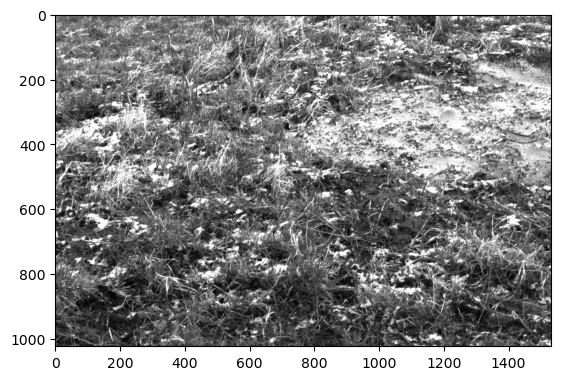

In [19]:
plt.imshow(frozen_images[2], cmap='gray')

In [13]:

# -----------------------------
# Reconstruct movies
# -----------------------------
frozen_movie = return_fix_movie(screen_size, frozen_images, frozen_fixations)

run_fix = running_fixations[whichRun - 1]
running_movie = return_fix_movie(screen_size, running_images, run_fix)

print("frozen_movie:", frozen_movie.shape)
print("running_movie:", running_movie.shape)

# -----------------------------
# Save to disk
# -----------------------------
os.makedirs("saved_movies", exist_ok=True)
os.makedirs("saved_plots", exist_ok=True)

save_movie(frozen_movie, "saved_movies/frozen_movie.mp4", fps=75)
save_movie(running_movie, f"saved_movies/running_movie_run{whichRun}.mp4", fps=75)


25 1024 1532
300 1024 1532


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (800, 600) to (800, 608) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


frozen_movie: (600, 800, 1875)
running_movie: (600, 800, 2625)


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (800, 600) to (800, 608) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


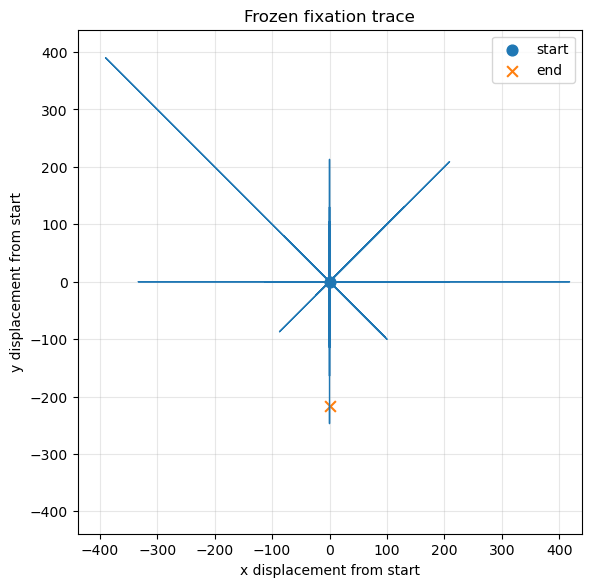

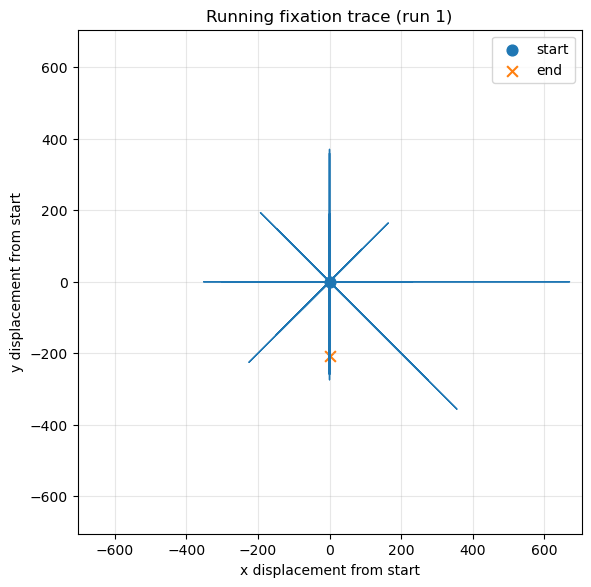

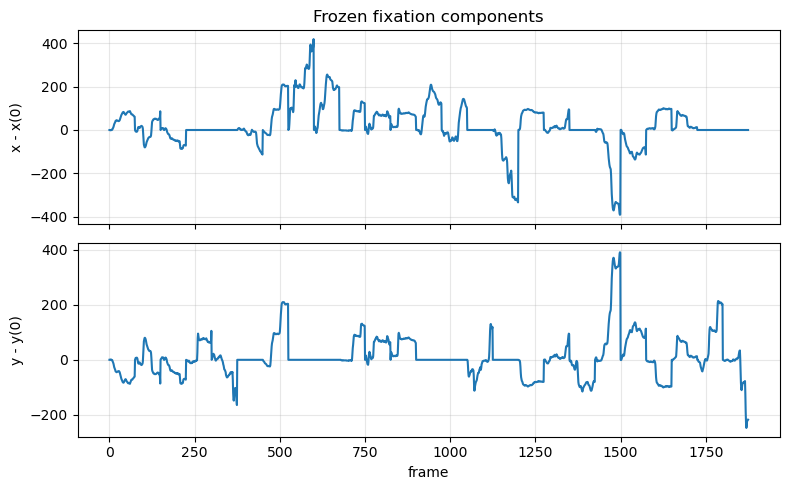

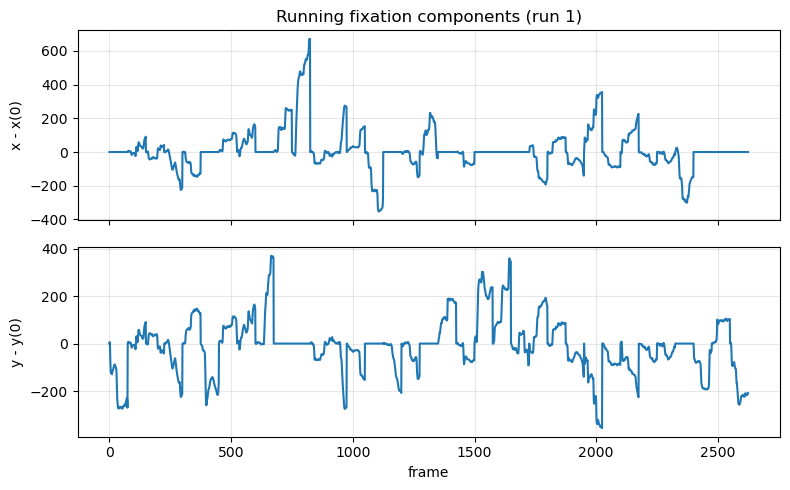

Saved videos to saved_movies/
Saved fixation plots to saved_plots/


In [14]:

# -----------------------------
# Plot fixation traces
# -----------------------------
plot_fixation_trace(
    frozen_fixations,
    title="Frozen fixation trace",
    out_path="saved_plots/frozen_fixation_trace.png",
    # screen_size=screen_size,
)

plot_fixation_trace(
    run_fix,
    title=f"Running fixation trace (run {whichRun})",
    out_path=f"saved_plots/running_fixation_trace_run{whichRun}.png",
    # screen_size=screen_size,
)

plot_fixation_components(
    frozen_fixations,
    title="Frozen fixation components",
    out_path="saved_plots/frozen_fixation_components.png",
)

plot_fixation_components(
    run_fix,
    title=f"Running fixation components (run {whichRun})",
    out_path=f"saved_plots/running_fixation_components_run{whichRun}.png",
)

print("Saved videos to saved_movies/")
print("Saved fixation plots to saved_plots/")

In [15]:
import os
import numpy as np
import matplotlib.pyplot as plt
import imageio.v3 as iio


def split_fixations_into_presentations(fixations, frames_per_image):
    """
    fixations: (n_frames, 3) with columns [image_idx, x, y]
    returns a list of fixation segments, each of shape (frames_per_image, 3)
    """
    n_frames = fixations.shape[0]
    n_segments = n_frames // frames_per_image

    segments = []
    for k in range(n_segments):
        seg = fixations[k * frames_per_image:(k + 1) * frames_per_image]
        segments.append(seg)

    return segments


def reconstruct_single_presentation(screen_size, image_stack, fixation_segment):
    """
    fixation_segment: (T, 3) for one image presentation
    returns movie: (H, W, T)
    """
    return return_fix_movie(screen_size, image_stack, fixation_segment)


def save_movie(movie, out_path, fps):
    frames = np.moveaxis(movie, 2, 0)  # (T, H, W)

    if frames.dtype != np.uint8:
        frames = frames.astype(np.float32)
        fmin, fmax = frames.min(), frames.max()
        if fmax > fmin:
            frames = 255 * (frames - fmin) / (fmax - fmin)
        else:
            frames = np.zeros_like(frames)
        frames = frames.astype(np.uint8)

    iio.imwrite(out_path, frames, fps=fps)


def plot_centered_trace(fixations, title, out_path=None):
    x = fixations[:, 1]
    y = fixations[:, 2]

    xc = x - x[0]
    yc = y - y[0]

    fig, ax = plt.subplots(figsize=(5, 5))
    ax.plot(xc, yc, lw=1.5)
    ax.scatter(0, 0, s=60, marker='o', label='start')
    ax.scatter(xc[-1], yc[-1], s=60, marker='x', label='end')
    ax.set_xlabel("x - x(0)")
    ax.set_ylabel("y - y(0)")
    ax.set_title(title)
    ax.set_aspect("equal")
    ax.grid(True, alpha=0.3)

    lim = max(np.max(np.abs(xc)), np.max(np.abs(yc))) * 1.05
    if lim > 0:
        ax.set_xlim(-lim, lim)
        ax.set_ylim(-lim, lim)

    ax.legend()
    fig.tight_layout()

    if out_path is not None:
        fig.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.close(fig)
    
frames_per_image = 75   # 1 second at 75 Hz

frozen_segments = split_fixations_into_presentations(frozen_fixations, frames_per_image=frames_per_image)

print("number of frozen presentations:", len(frozen_segments))
print("first segment shape:", frozen_segments[0].shape)

os.makedirs("saved_movies/frozen_presentations", exist_ok=True)
os.makedirs("saved_plots/frozen_presentations", exist_ok=True)

for i, seg in enumerate(frozen_segments):
    movie_i = reconstruct_single_presentation(screen_size, frozen_images, seg)

    img_id = int(seg[0, 0])

    save_movie(
        movie_i,
        f"saved_movies/frozen_presentations/frozen_presentation_{i:03d}_img{img_id:03d}.mp4",
        fps=75
    )

    plot_centered_trace(
        seg,
        title=f"Frozen presentation {i} | image {img_id}",
        out_path=f"saved_plots/frozen_presentations/frozen_presentation_{i:03d}_img{img_id:03d}_trace.png"
    )

number of frozen presentations: 25
first segment shape: (75, 3)
25 1024 1532


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (800, 600) to (800, 608) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


25 1024 1532


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (800, 600) to (800, 608) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


25 1024 1532


...

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (800, 600) to (800, 608) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


25 1024 1532


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (800, 600) to (800, 608) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


25 1024 1532


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (800, 600) to (800, 608) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).
